# 06: Logistic Regression

## 1. Imports

In [1]:
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.calibration import CalibrationDisplay

from src.config import PROJECT_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    TRAIN_CLEAN_PATH,
    TRAIN_FEATURED_PATH,
    SPLIT_MANIFEST_PATH,
    MODELS_DIR,
    RESULTS_DIR,
    TARGET,
    ID_COLUMN,
    RANDOM_STATE,
)

pd.set_option("display.max_columns", 100)

## Load Dataset

In [2]:
clean = pd.read_csv(TRAIN_CLEAN_PATH)
featured = pd.read_csv(TRAIN_FEATURED_PATH)
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)

train_ids = set(
    manifest.loc[
        manifest["Split"] == "train",
        ID_COLUMN,
    ]
)

holdout_ids = set(
    manifest.loc[
        manifest["Split"] == "test",
        ID_COLUMN,
    ]
)

def split_by_manifest(df):
    development = (
        df[df[ID_COLUMN].isin(train_ids)]
        .sort_values(ID_COLUMN)
        .reset_index(drop=True)
    )

    holdout = (
        df[df[ID_COLUMN].isin(holdout_ids)]
        .sort_values(ID_COLUMN)
        .reset_index(drop=True)
    )

    return development, holdout

clean_dev, clean_holdout = split_by_manifest(clean)
featured_dev, featured_holdout = split_by_manifest(featured)

print("Development rows:", len(clean_dev))
print("Holdout rows:", len(clean_holdout))
print("Development attrition rate:", f"{clean_dev[TARGET].mean():.1%}")
print("Holdout attrition rate:", f"{clean_holdout[TARGET].mean():.1%}")

Development rows: 846
Holdout rows: 212
Development attrition rate: 16.9%
Holdout attrition rate: 17.0%


## 3. Build Pipeline

In [3]:
def build_logistic_pipeline(
    X,
    C=1.0,
    l1_ratio=0.0,
    class_weight=None,
):
    categorical_columns = [
        column for column in X.columns
        if not pd.api.types.is_numeric_dtype(X[column])
    ]

    numeric_columns = [
        column for column in X.columns
        if column not in categorical_columns
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

    classifier = LogisticRegression(
        C=C,
        l1_ratio=l1_ratio,
        class_weight=class_weight,
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])

## 4. Compare Features (Original vs. Engineered)

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

comparison_rows = []

for feature_set_name, development_df in [
    ("Original cleaned features", clean_dev),
    ("Engineered candidate features", featured_dev),
]:
    X = development_df.drop(columns=[TARGET, ID_COLUMN])
    y = development_df[TARGET]

    pipeline = build_logistic_pipeline(X)

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
        },
        n_jobs=-1,
    )

    comparison_rows.append({
        "feature_set": feature_set_name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_pr_auc_std": scores["test_pr_auc"].std(),
    })

feature_comparison = pd.DataFrame(comparison_rows)

feature_comparison.round(4)

,feature_set,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Original cleaned features,0.8295,0.0418,0.6257,0.0577
1,Engineered candidate features,0.8342,0.0367,0.6363,0.0433


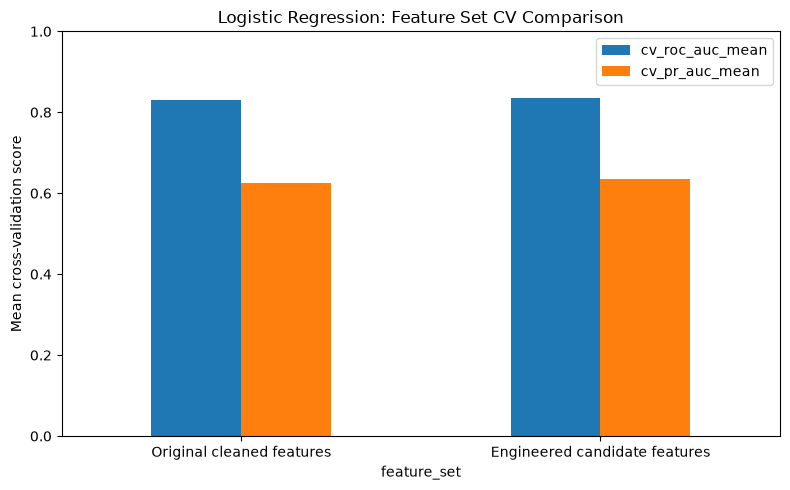

In [5]:
plot_data = feature_comparison.set_index("feature_set")[
    ["cv_roc_auc_mean", "cv_pr_auc_mean"]
]

plot_data.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Logistic Regression: Feature Set CV Comparison")
plt.ylabel("Mean cross-validation score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
selected_name = (
    feature_comparison
    .sort_values("cv_pr_auc_mean", ascending=False)
    .iloc[0]["feature_set"]
)

print("Selected feature set:", selected_name)

if selected_name == "Engineered candidate features":
    development = featured_dev
    holdout = featured_holdout
else:
    development = clean_dev
    holdout = clean_holdout

X_dev = development.drop(columns=[TARGET, ID_COLUMN])
y_dev = development[TARGET]

X_holdout = holdout.drop(columns=[TARGET, ID_COLUMN])
y_holdout = holdout[TARGET]

Selected feature set: Engineered candidate features


## 5. Tune Model
We tune:

- **C** — inverse regularization strength
- **l1_ratio** — `0` for L2 or `1` for L1 regularization
- **class_weight** — ordinary or class-balanced weighting

`liblinear` supports both pure L1 (`l1_ratio=1`) and pure L2 (`l1_ratio=0`) regularization for binary Logistic Regression and works well for a dataset of this size.

The grid search refits the configuration with the best mean **PR-AUC**.

In [7]:
pipeline = build_logistic_pipeline(X_dev)

param_grid = {
    "classifier__C": [
        0.01,
        0.03,
        0.1,
        0.3,
        1.0,
        3.0,
        10.0,
    ],
    "classifier__l1_ratio": [
        0.0,  # L2
        1.0,  # L1
    ],
    "classifier__class_weight": [
        None,
        "balanced",
    ],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={
        "pr_auc": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "recall": "recall",
        "f1": "f1",
    },
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
)

grid.fit(X_dev, y_dev)

print("Best parameters:")
print(grid.best_params_)
print()
print("Best CV PR-AUC:", round(grid.best_score_, 4))

Best parameters:
{'classifier__C': 0.03, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.0}

Best CV PR-AUC: 0.6571


In [8]:
tuning_results = pd.DataFrame(grid.cv_results_)

tuning_view = tuning_results[[
    "param_classifier__C",
    "param_classifier__l1_ratio",
    "param_classifier__class_weight",
    "mean_test_pr_auc",
    "std_test_pr_auc",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_recall",
    "mean_test_f1",
    "rank_test_pr_auc",
]].sort_values("rank_test_pr_auc")

tuning_view.head(10).round(4)

,param_classifier__C,param_classifier__l1_ratio,param_classifier__class_weight,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_recall,mean_test_f1,rank_test_pr_auc
4,0.03,0.0,NaN,0.6571,0.0444,0.8305,0.6394,0.2931,0.4279,1
13,0.30,1.0,NaN,0.6560,0.0643,0.8286,0.6719,0.3695,0.4876,2
8,0.10,0.0,NaN,0.6511,0.0464,0.8320,0.6762,0.3766,0.4997,3
17,1.00,1.0,NaN,0.6500,0.0494,0.8335,0.6995,0.4333,0.5415,4
12,0.30,0.0,NaN,0.6475,0.0475,0.8334,0.6961,0.4192,0.5391,5
0,0.01,0.0,NaN,0.6453,0.0346,0.8243,0.6075,0.2165,0.3513,6
2,0.01,0.0,balanced,0.6382,0.0581,0.8223,0.7509,0.7350,0.5111,7
16,1.00,0.0,NaN,0.6363,0.0433,0.8342,0.6982,0.4335,0.5352,8
6,0.03,0.0,balanced,0.6352,0.0578,0.8263,0.7602,0.7352,0.5275,9
21,3.00,1.0,NaN,0.6300,0.0481,0.8324,0.7004,0.4406,0.5381,10


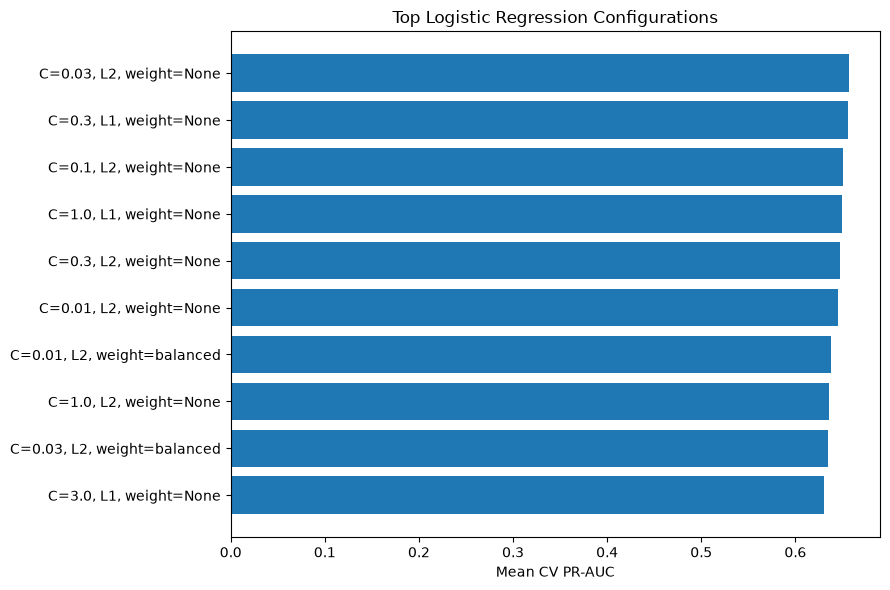

In [9]:
top_tuning = tuning_view.head(10).copy()

def configuration_label(row):
    penalty = (
        "L1"
        if float(row["param_classifier__l1_ratio"]) == 1.0
        else "L2"
    )

    class_weight = row["param_classifier__class_weight"]

    if pd.isna(class_weight):
        class_weight = "None"

    return (
        f"C={row['param_classifier__C']}, "
        f"{penalty}, "
        f"weight={class_weight}"
    )


top_tuning["configuration"] = top_tuning.apply(
    configuration_label,
    axis=1,
)

# Make sure the plotting values are numeric
top_tuning["mean_test_pr_auc"] = pd.to_numeric(
    top_tuning["mean_test_pr_auc"]
)

top_tuning = (
    top_tuning
    .sort_values("mean_test_pr_auc")
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_tuning["configuration"].astype(str),
    top_tuning["mean_test_pr_auc"],
)

plt.xlabel("Mean CV PR-AUC")
plt.title("Top Logistic Regression Configurations")
plt.tight_layout()
plt.show()

## 6. Evaluate Model

In [10]:
best_model = grid.best_estimator_

holdout_probability = best_model.predict_proba(
    X_holdout
)[:, 1]

holdout_prediction = best_model.predict(
    X_holdout
)

metrics = pd.DataFrame([{
    "accuracy": accuracy_score(
        y_holdout,
        holdout_prediction,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_holdout,
        holdout_prediction,
    ),
    "precision": precision_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "f1": f1_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_holdout,
        holdout_probability,
    ),
    "pr_auc": average_precision_score(
        y_holdout,
        holdout_probability,
    ),
    "brier_score": brier_score_loss(
        y_holdout,
        holdout_probability,
    ),
}])

metrics.round(4)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,0.8538,0.6136,0.6923,0.25,0.3673,0.8278,0.5489,0.1087


## 7. Confusion Matrix

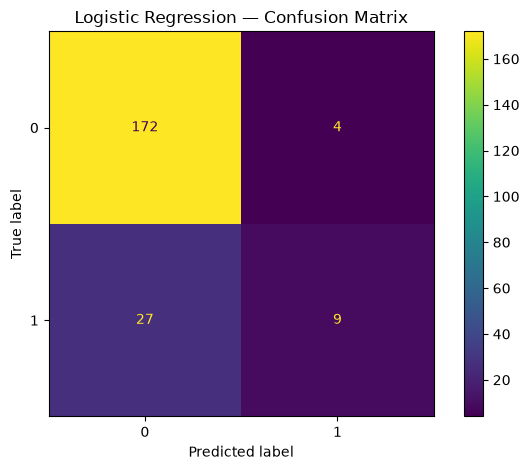

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_prediction,
)

plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. ROC Curve

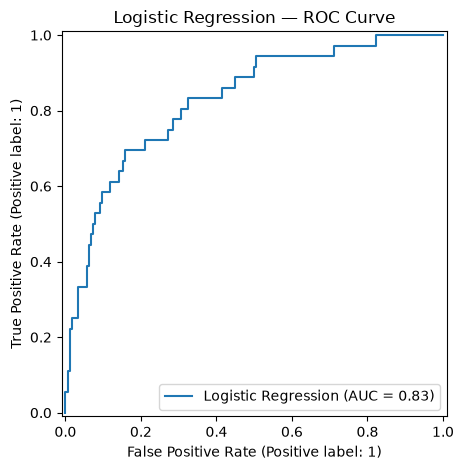

In [12]:
RocCurveDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    name="Logistic Regression",
)

plt.title("Logistic Regression — ROC Curve")
plt.tight_layout()
plt.show()

## 9. Precision-Recall Curve

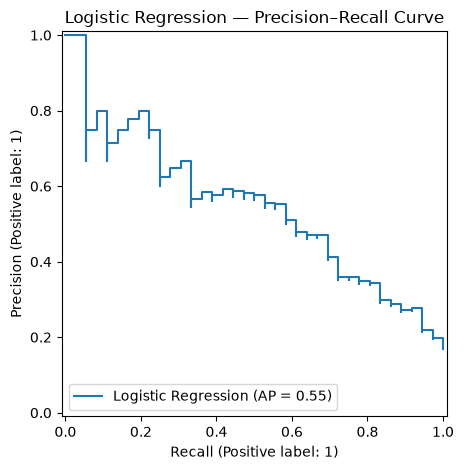

In [13]:
PrecisionRecallDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    name="Logistic Regression",
)

plt.title("Logistic Regression — Precision–Recall Curve")
plt.tight_layout()
plt.show()

## 10. Prediction Probability Distributions

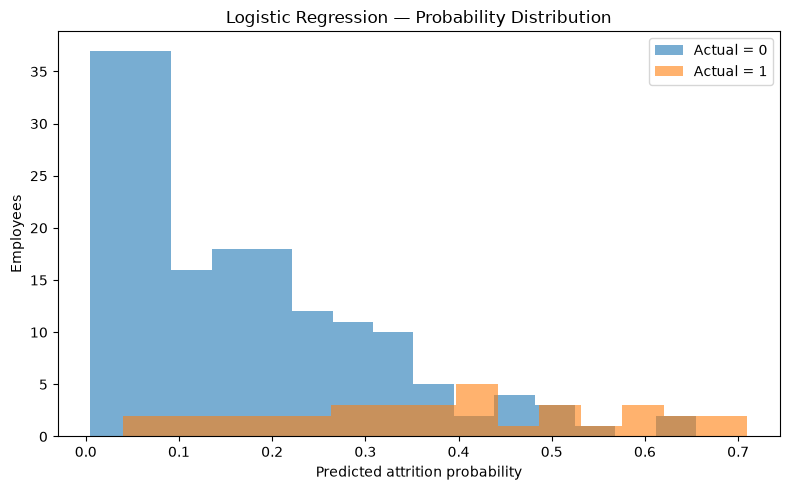

In [14]:
probability_frame = pd.DataFrame({
    "Actual": y_holdout.values,
    "Probability": holdout_probability,
})

plt.figure(figsize=(8, 5))

for actual_value in sorted(
    probability_frame["Actual"].unique()
):
    values = probability_frame.loc[
        probability_frame["Actual"] == actual_value,
        "Probability",
    ]

    plt.hist(
        values,
        bins=15,
        alpha=0.6,
        label=f"Actual = {actual_value}",
    )

plt.xlabel("Predicted attrition probability")
plt.ylabel("Employees")
plt.title("Logistic Regression — Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Calibration

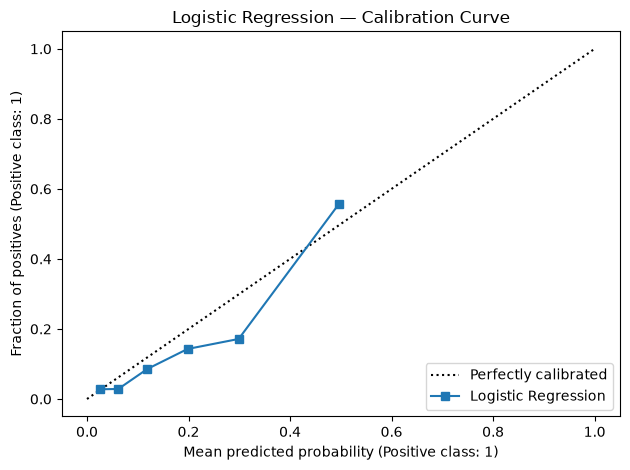

In [15]:
CalibrationDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    n_bins=6,
    strategy="quantile",
    name="Logistic Regression",
)

plt.title("Logistic Regression — Calibration Curve")
plt.tight_layout()
plt.show()

## 12. Coefficients and Odds Ratios

In [16]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.split("__", 1)[-1]
    if "__" in name
    else name
    for name in feature_names
]

coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": classifier.coef_[0],
})

coefficients["odds_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients["abs_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "abs_coefficient",
    ascending=False,
)

coefficients.head(20)

,feature,coefficient,odds_ratio,abs_coefficient
58,OverTime_No,-0.560855,0.570721,0.560855
36,Department_Research & Development,-0.359213,0.698226,0.359213
31,OverTimeJobInvolvement,0.295140,1.343314,0.295140
34,BusinessTravel_Travel_Rarely,-0.273394,0.760793,0.273394
6,JobInvolvement,-0.260687,0.770522,0.260687
39,EducationField_Life Sciences,-0.257259,0.773168,0.257259
15,StockOptionLevel,-0.256961,0.773398,0.256961
55,MaritalStatus_Divorced,-0.252112,0.777157,0.252112
44,Gender_Female,-0.248256,0.780160,0.248256
28,SatisfactionAverage,-0.240193,0.786476,0.240193


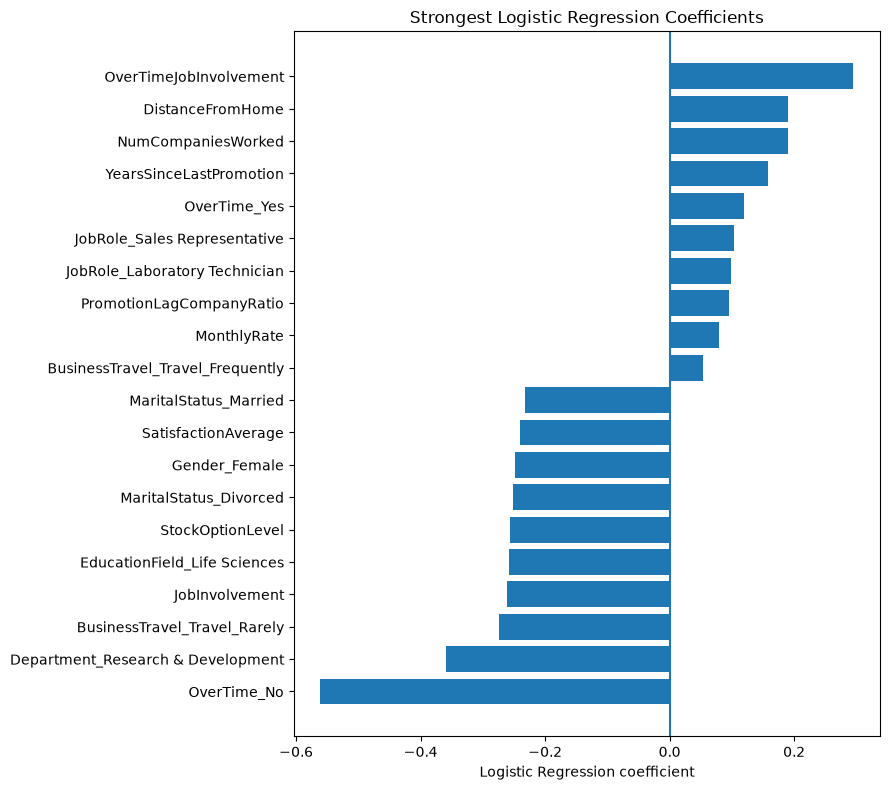

In [17]:
largest_positive = (
    coefficients
    .sort_values("coefficient", ascending=False)
    .head(10)
)

largest_negative = (
    coefficients
    .sort_values("coefficient", ascending=True)
    .head(10)
)

coefficient_plot = pd.concat([
    largest_negative,
    largest_positive,
]).sort_values("coefficient")

plt.figure(figsize=(9, 8))
plt.barh(
    coefficient_plot["feature"],
    coefficient_plot["coefficient"],
)

plt.axvline(0)
plt.xlabel("Logistic Regression coefficient")
plt.title("Strongest Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

## 13. Compare to Baseline

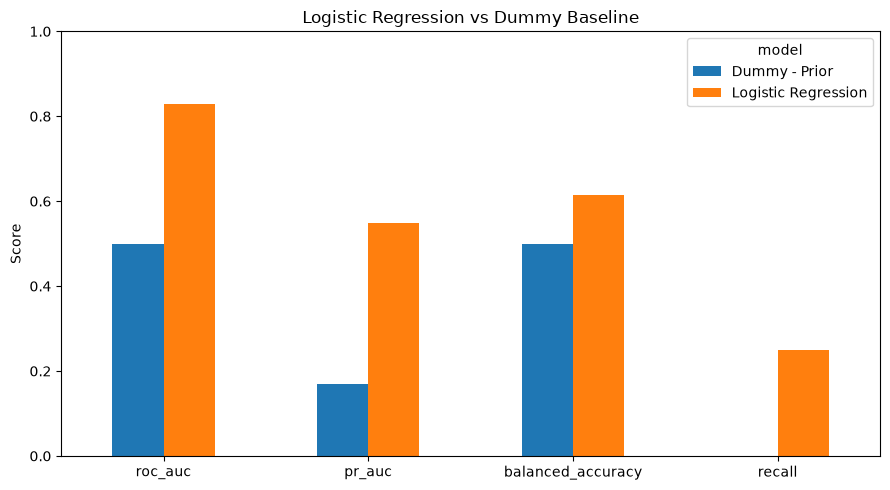

In [18]:
baseline_path = RESULTS_DIR / "baseline_results.csv"

if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)

    comparison = pd.DataFrame([
        {
            "model": "Dummy - Prior",
            "roc_auc": baseline.loc[
                baseline["model"] == "Dummy - Prior",
                "roc_auc",
            ].iloc[0],
            "pr_auc": baseline.loc[
                baseline["model"] == "Dummy - Prior",
                "pr_auc",
            ].iloc[0],
            "balanced_accuracy": baseline.loc[
                baseline["model"] == "Dummy - Prior",
                "balanced_accuracy",
            ].iloc[0],
            "recall": baseline.loc[
                baseline["model"] == "Dummy - Prior",
                "recall",
            ].iloc[0],
        },
        {
            "model": "Logistic Regression",
            "roc_auc": metrics["roc_auc"].iloc[0],
            "pr_auc": metrics["pr_auc"].iloc[0],
            "balanced_accuracy": metrics[
                "balanced_accuracy"
            ].iloc[0],
            "recall": metrics["recall"].iloc[0],
        },
    ])

    comparison.set_index("model").T.plot(
        kind="bar",
        figsize=(9, 5),
    )

    plt.title("Logistic Regression vs Dummy Baseline")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    comparison.round(4)
else:
    print("Baseline results file not found.")

## 14. Save Results

In [19]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

feature_comparison.to_csv(
    RESULTS_DIR / "logistic_feature_set_comparison.csv",
    index=False,
)

tuning_view.to_csv(
    RESULTS_DIR / "logistic_tuning_results.csv",
    index=False,
)

model_results = metrics.copy()

model_results.insert(
    0,
    "model",
    "Logistic Regression",
)

model_results["feature_set"] = selected_name
model_results["best_C"] = grid.best_params_[
    "classifier__C"
]
model_results["best_l1_ratio"] = grid.best_params_[
    "classifier__l1_ratio"
]

model_results["best_penalty"] = np.where(
    model_results["best_l1_ratio"].astype(float) == 1.0,
    "L1",
    "L2",
)
model_results["best_class_weight"] = str(
    grid.best_params_["classifier__class_weight"]
)
model_results["cv_pr_auc"] = grid.best_score_

model_results.to_csv(
    RESULTS_DIR / "logistic_regression_results.csv",
    index=False,
)

holdout_predictions = pd.DataFrame({
    ID_COLUMN: holdout[ID_COLUMN].values,
    "Actual": y_holdout.values,
    "Predicted": holdout_prediction,
    "AttritionProbability": holdout_probability,
})

holdout_predictions.to_csv(
    RESULTS_DIR / "logistic_holdout_predictions.csv",
    index=False,
)

coefficients.to_csv(
    RESULTS_DIR / "logistic_coefficients.csv",
    index=False,
)

joblib.dump(
    best_model,
    MODELS_DIR / "logistic_regression_pipeline.joblib",
)

print("Results saved to:", RESULTS_DIR)
print("Model saved to:", MODELS_DIR)

Results saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
Model saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\models
